# 📊 Notebook 2: Exploratory Data Analysis (EDA)
## ISIC 2024 Skin Cancer Detection

**Objective:** Load the full 401K-sample dataset and uncover insights that directly drive 
our modeling and preprocessing decisions.

> **Principle:** Every plot and statistic must answer:  
> *"What modeling/preprocessing decision does this insight inform?"*

---

In [1]:
# ============================================================
# Setup & Imports
# ============================================================
import os, sys, io, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from PIL import Image
from scipy import stats
from collections import Counter
from IPython.display import display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12, 'axes.titlesize': 14})

SEED = 42
np.random.seed(SEED)

ROOT = os.getcwd()

DATA_DIR = os.path.join(ROOT, 'ISIC 2024 Skin Cancer Challenge Dataset')
FIG_DIR  = os.path.join(ROOT, 'outputs', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)



## 2.1 Loading the Full Dataset

We load **all 401,059** training samples with no subsampling.

In [2]:
# ============================================================
# 2.1 — Load Complete Training Metadata
# ============================================================
TRAIN_META = os.path.join(DATA_DIR, 'train-metadata.csv')
df = pd.read_csv(TRAIN_META, low_memory=False)

mem_mb = df.memory_usage(deep=True).sum() / 1e6
n0, n1 = int((df['target'] == 0).sum()), int((df['target'] == 1).sum())
imb_ratio = n0 / max(n1, 1)

load_summary = pd.DataFrame(
    [
        {'metric': 'rows', 'value': f"{len(df):,}"},
        {'metric': 'columns', 'value': df.shape[1]},
        {'metric': 'memory_usage_MB', 'value': f"{mem_mb:.1f}"},
        {'metric': 'benign_count', 'value': f"{n0:,}"},
        {'metric': 'malignant_count', 'value': f"{n1:,}"},
        {'metric': 'malignant_rate_pct', 'value': f"{df['target'].mean() * 100:.4f}"},
        {'metric': 'imbalance_ratio_benign_to_malignant', 'value': f"{imb_ratio:.1f}:1"},
        {'metric': 'unique_patients', 'value': f"{df['patient_id'].nunique():,}"},
    ]
)
display(load_summary)

display(df['target'].value_counts().rename('count').to_frame())
display(df['iddx_1'].value_counts().rename('count').to_frame())



,metric,value
0,rows,"401,059"
1,columns,55
2,memory_usage_MB,497.4
3,benign_count,"400,666"
4,malignant_count,393
5,malignant_rate_pct,0.0980
6,imbalance_ratio_benign_to_malignant,1019.5:1
7,unique_patients,"1,042"


,count
target,
0,400666
1,393


,count
iddx_1,
Benign,400552
Malignant,393
Indeterminate,114


In [3]:
# ============================================================
# 2.2 — Data Types & Missing Values Overview
# ============================================================
info_df = pd.DataFrame({
    'Type': df.dtypes,
    'Non-Null': df.count(),
    'Missing': df.isnull().sum(),
    'Missing%': (df.isnull().sum() / len(df) * 100).round(3),
    'Unique': df.nunique(),
    'Sample': [df[c].dropna().iloc[0] if df[c].count() > 0 else 'ALL NULL' for c in df.columns],
})

display(info_df)

missing = info_df[info_df['Missing'] > 0][['Missing', 'Missing%']]
if len(missing) > 0:
    display(missing)
else:
    display(pd.DataFrame([{'note': 'No columns with missing values'}]))



,Type,Non-Null,Missing,Missing%,Unique,Sample
isic_id,str,401059,0,0.000,401059,ISIC_0015670
target,int64,401059,0,0.000,2,0
patient_id,str,401059,0,0.000,1042,IP_1235828
age_approx,float64,398261,2798,0.698,16,60.0
sex,str,389542,11517,2.872,2,male
anatom_site_general,str,395303,5756,1.435,5,lower extremity
clin_size_long_diam_mm,float64,401059,0,0.000,1758,3.04
image_type,str,401059,0,0.000,1,TBP tile: close-up
tbp_tile_type,str,401059,0,0.000,2,3D: white
tbp_lv_A,float64,401059,0,0.000,386052,20.244422


,Missing,Missing%
age_approx,2798,0.698
sex,11517,2.872
anatom_site_general,5756,1.435
lesion_id,379001,94.500
iddx_2,399991,99.734
iddx_3,399994,99.734
iddx_4,400508,99.863
iddx_5,401058,100.000
mel_mitotic_index,401006,99.987
mel_thick_mm,400996,99.984


## 2.2 Class Imbalance Analysis

> **Why this matters:** With only ~393 malignant out of 401K samples (0.098%), the class imbalance 
> is extreme (~1020:1). A naive model predicting all-benign achieves 99.9% accuracy but is clinically 
> useless. Our evaluation must use ranking metrics (AUC) not accuracy.

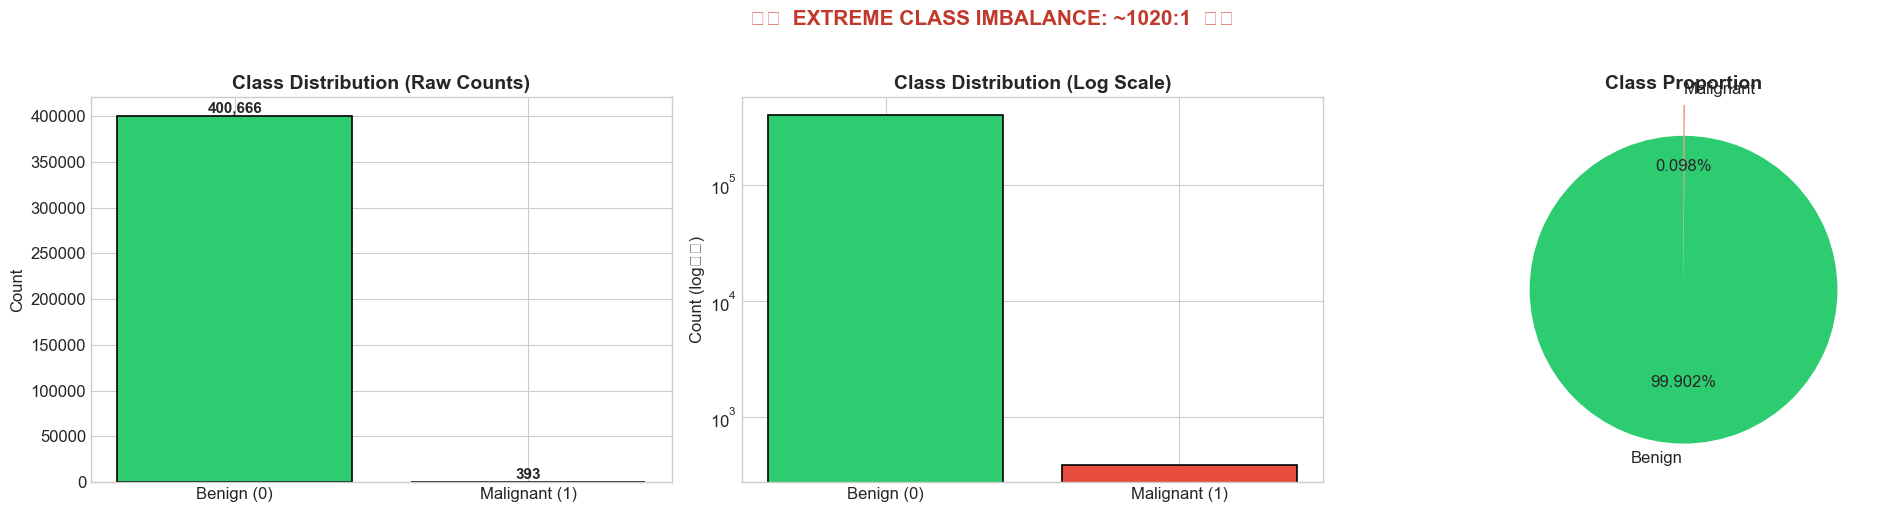

In [4]:
# ============================================================
# 2.2 — Class Imbalance Visualization
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors = ['#2ecc71', '#e74c3c']
target_counts = df['target'].value_counts().sort_index()

# Raw counts
bars = axes[0].bar(['Benign (0)', 'Malignant (1)'], target_counts.values,
                   color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Class Distribution (Raw Counts)', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Log scale
axes[1].bar(['Benign (0)', 'Malignant (1)'], target_counts.values,
            color=colors, edgecolor='black', linewidth=1.2)
axes[1].set_yscale('log')
axes[1].set_title('Class Distribution (Log Scale)', fontweight='bold')
axes[1].set_ylabel('Count (log₁₀)')

# Pie
pct_benign = (1 - df['target'].mean()) * 100
pct_malig  = df['target'].mean() * 100
axes[2].pie([pct_benign, pct_malig], labels=['Benign', 'Malignant'],
            colors=colors, autopct='%1.3f%%', startangle=90,
            explode=(0, 0.2), textprops={'fontsize': 12})
axes[2].set_title('Class Proportion', fontweight='bold')

plt.suptitle('⚠️  EXTREME CLASS IMBALANCE: ~1020:1  ⚠️',
             fontsize=15, fontweight='bold', color='#c0392b', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_class_imbalance.png'), dpi=150, bbox_inches='tight')
plt.show()


### 📌 INSIGHT → Extreme imbalance (~1020:1)
**DECISIONS:**
1. **`scale_pos_weight=1020`** in LightGBM/XGBoost
2. **Focal Loss** for CNN (γ=2 to focus on hard examples)
3. **StratifiedGroupKFold** to preserve ratio limit + prevent leakage
4. **pAUC** above **88% TPR** (ISIC 2024 primary metric) rather than accuracy alone

## 2.3 Demographic Analysis

Understanding how patient demographics relate to malignancy to determine whether they are 
predictive features and what interactions to engineer.

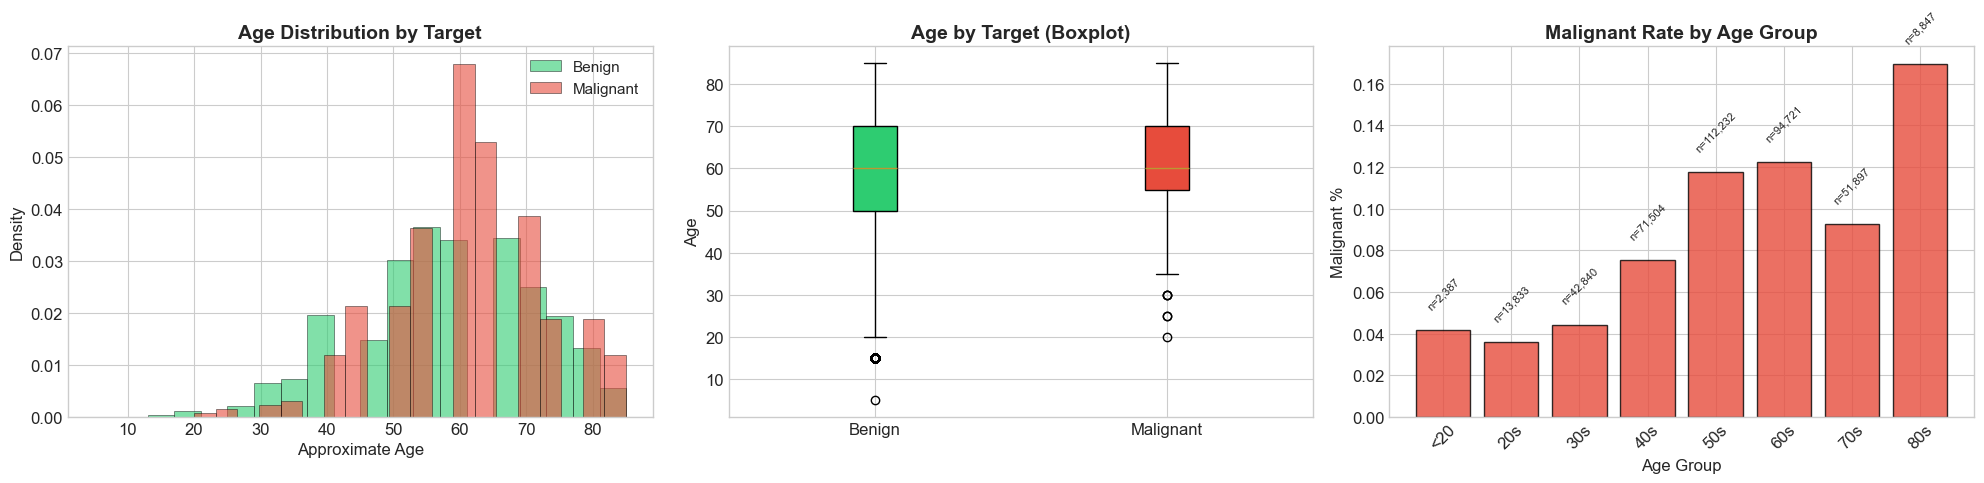

,group,n,mean_age
0,Benign,397871,58.009694
1,Malignant,390,61.371795


,Mann-Whitney_U,p_value_two_sided
0,88535852.5,0.000001


In [5]:
# ============================================================
# 2.3a — Age Distribution by Target
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Age histograms
for t, color, label in [(0, '#2ecc71', 'Benign'), (1, '#e74c3c', 'Malignant')]:
    subset = df[df['target'] == t]['age_approx'].dropna()
    axes[0].hist(subset, bins=20, alpha=0.6, color=color, label=label,
                 density=True, edgecolor='black', linewidth=0.5)
axes[0].set_title('Age Distribution by Target', fontweight='bold')
axes[0].set_xlabel('Approximate Age')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=11)

# Age boxplot
data_age = [df[df['target']==0]['age_approx'].dropna(),
            df[df['target']==1]['age_approx'].dropna()]
bp = axes[1].boxplot(data_age, labels=['Benign', 'Malignant'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Age by Target (Boxplot)', fontweight='bold')
axes[1].set_ylabel('Age')

# Malignant rate by age group
df['age_bin'] = pd.cut(df['age_approx'], bins=[0,20,30,40,50,60,70,80,90,100],
                       labels=['<20','20s','30s','40s','50s','60s','70s','80s','90s'])
age_rate = df.groupby('age_bin')['target'].agg(['mean','count'])
ax2 = axes[2]
bars = ax2.bar(range(len(age_rate)), age_rate['mean']*100, color='#e74c3c',
              edgecolor='black', alpha=0.8)
ax2.set_xticks(range(len(age_rate)))
ax2.set_xticklabels(age_rate.index, rotation=45)
ax2.set_title('Malignant Rate by Age Group', fontweight='bold')
ax2.set_ylabel('Malignant %')
ax2.set_xlabel('Age Group')
# Add sample counts
for i, (_, row) in enumerate(age_rate.iterrows()):
    ax2.text(i, row['mean']*100 + 0.01, f'n={int(row["count"]):,}',
            ha='center', fontsize=8, rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_age_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# Statistical test
from scipy.stats import mannwhitneyu
b_age = df[df['target']==0]['age_approx'].dropna()
m_age = df[df['target']==1]['age_approx'].dropna()
U, p = mannwhitneyu(m_age, b_age, alternative='two-sided')

age_stats = pd.DataFrame(
    {
        'group': ['Benign', 'Malignant'],
        'n': [len(b_age), len(m_age)],
        'mean_age': [b_age.mean(), m_age.mean()],
    }
)
display(age_stats)
display(pd.DataFrame([{'Mann-Whitney_U': U, 'p_value_two_sided': p}]))

df.drop('age_bin', axis=1, inplace=True)



### 📌 Age distribution — interpretation

The **Mann–Whitney U** test and the **group mean ages** are computed in the code cell above and shown as tables (not printed text).

**Insight:** Malignant lesions tend to occur in **older** patients than benign lesions; the difference is statistically significant at conventional levels.

**Decision:** Keep `age_approx` as a continuous feature; consider age-bin or interaction features if a linear model is used.



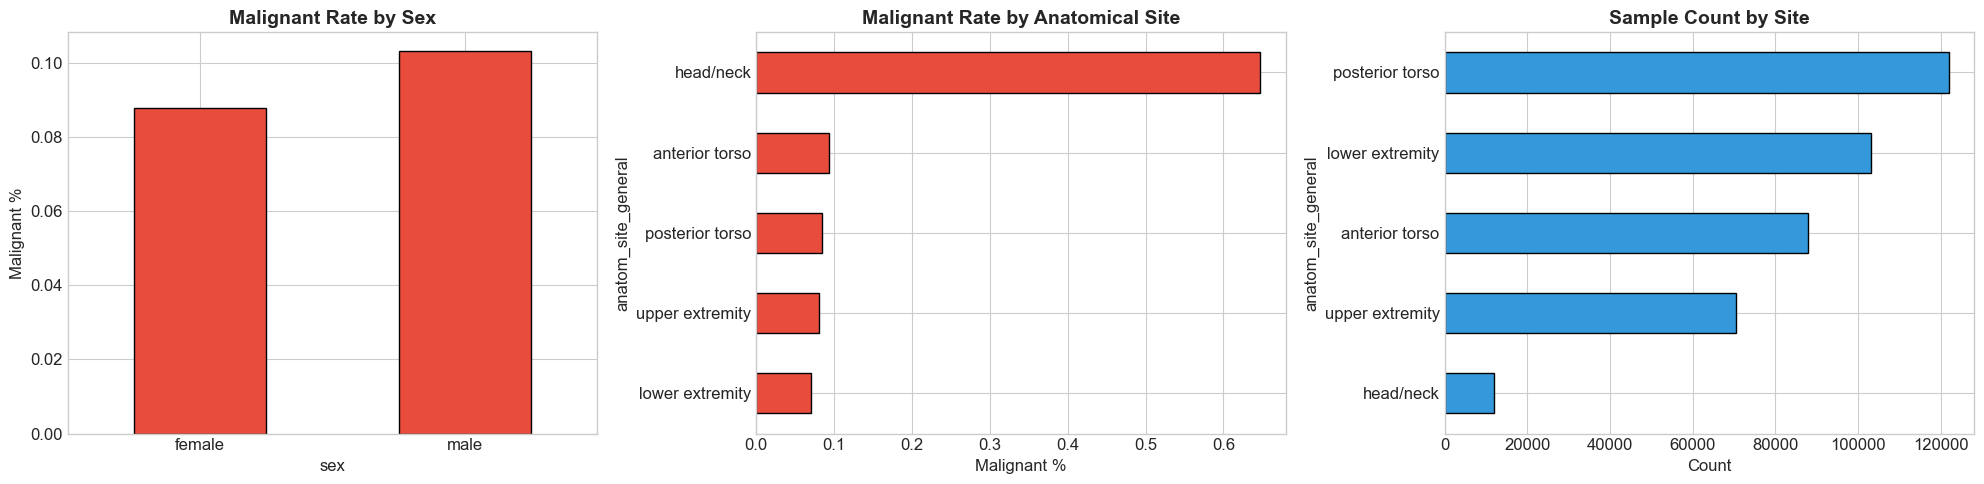

In [6]:
# ============================================================
# 2.3b — Sex & Anatomical Site Analysis
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Sex distribution
sex_counts = df.groupby(['sex', 'target']).size().unstack(fill_value=0)
sex_pct = sex_counts.div(sex_counts.sum(axis=1), axis=0) * 100
sex_pct[1].plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Malignant Rate by Sex', fontweight='bold')
axes[0].set_ylabel('Malignant %')
axes[0].tick_params(axis='x', rotation=0)

# Anatomical site distribution
site_counts = df.groupby(['anatom_site_general', 'target']).size().unstack(fill_value=0)
site_pct = site_counts.div(site_counts.sum(axis=1), axis=0) * 100
site_pct[1].sort_values().plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Malignant Rate by Anatomical Site', fontweight='bold')
axes[1].set_xlabel('Malignant %')

# Site sample sizes
site_total = df['anatom_site_general'].value_counts()
site_total.sort_values().plot(kind='barh', ax=axes[2], color='#3498db', edgecolor='black')
axes[2].set_title('Sample Count by Site', fontweight='bold')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_sex_site_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()



### 📌 Sex & Anatomical Site Insights
1. **Sex**: Males may have slightly different malignancy rates → include as a feature.
2. **Anatomical site**: Head/neck shows different rates → create site-risk encoding.

**DECISION:** Label-encode sex & site; create site-level target-rate features (be careful of target leakage).

## 2.4 TBP Feature Analysis

The Total Body Photography system provides 40+ quantitative features per lesion. We analyze their 
distributions and discriminative power to identify the most informative signals.

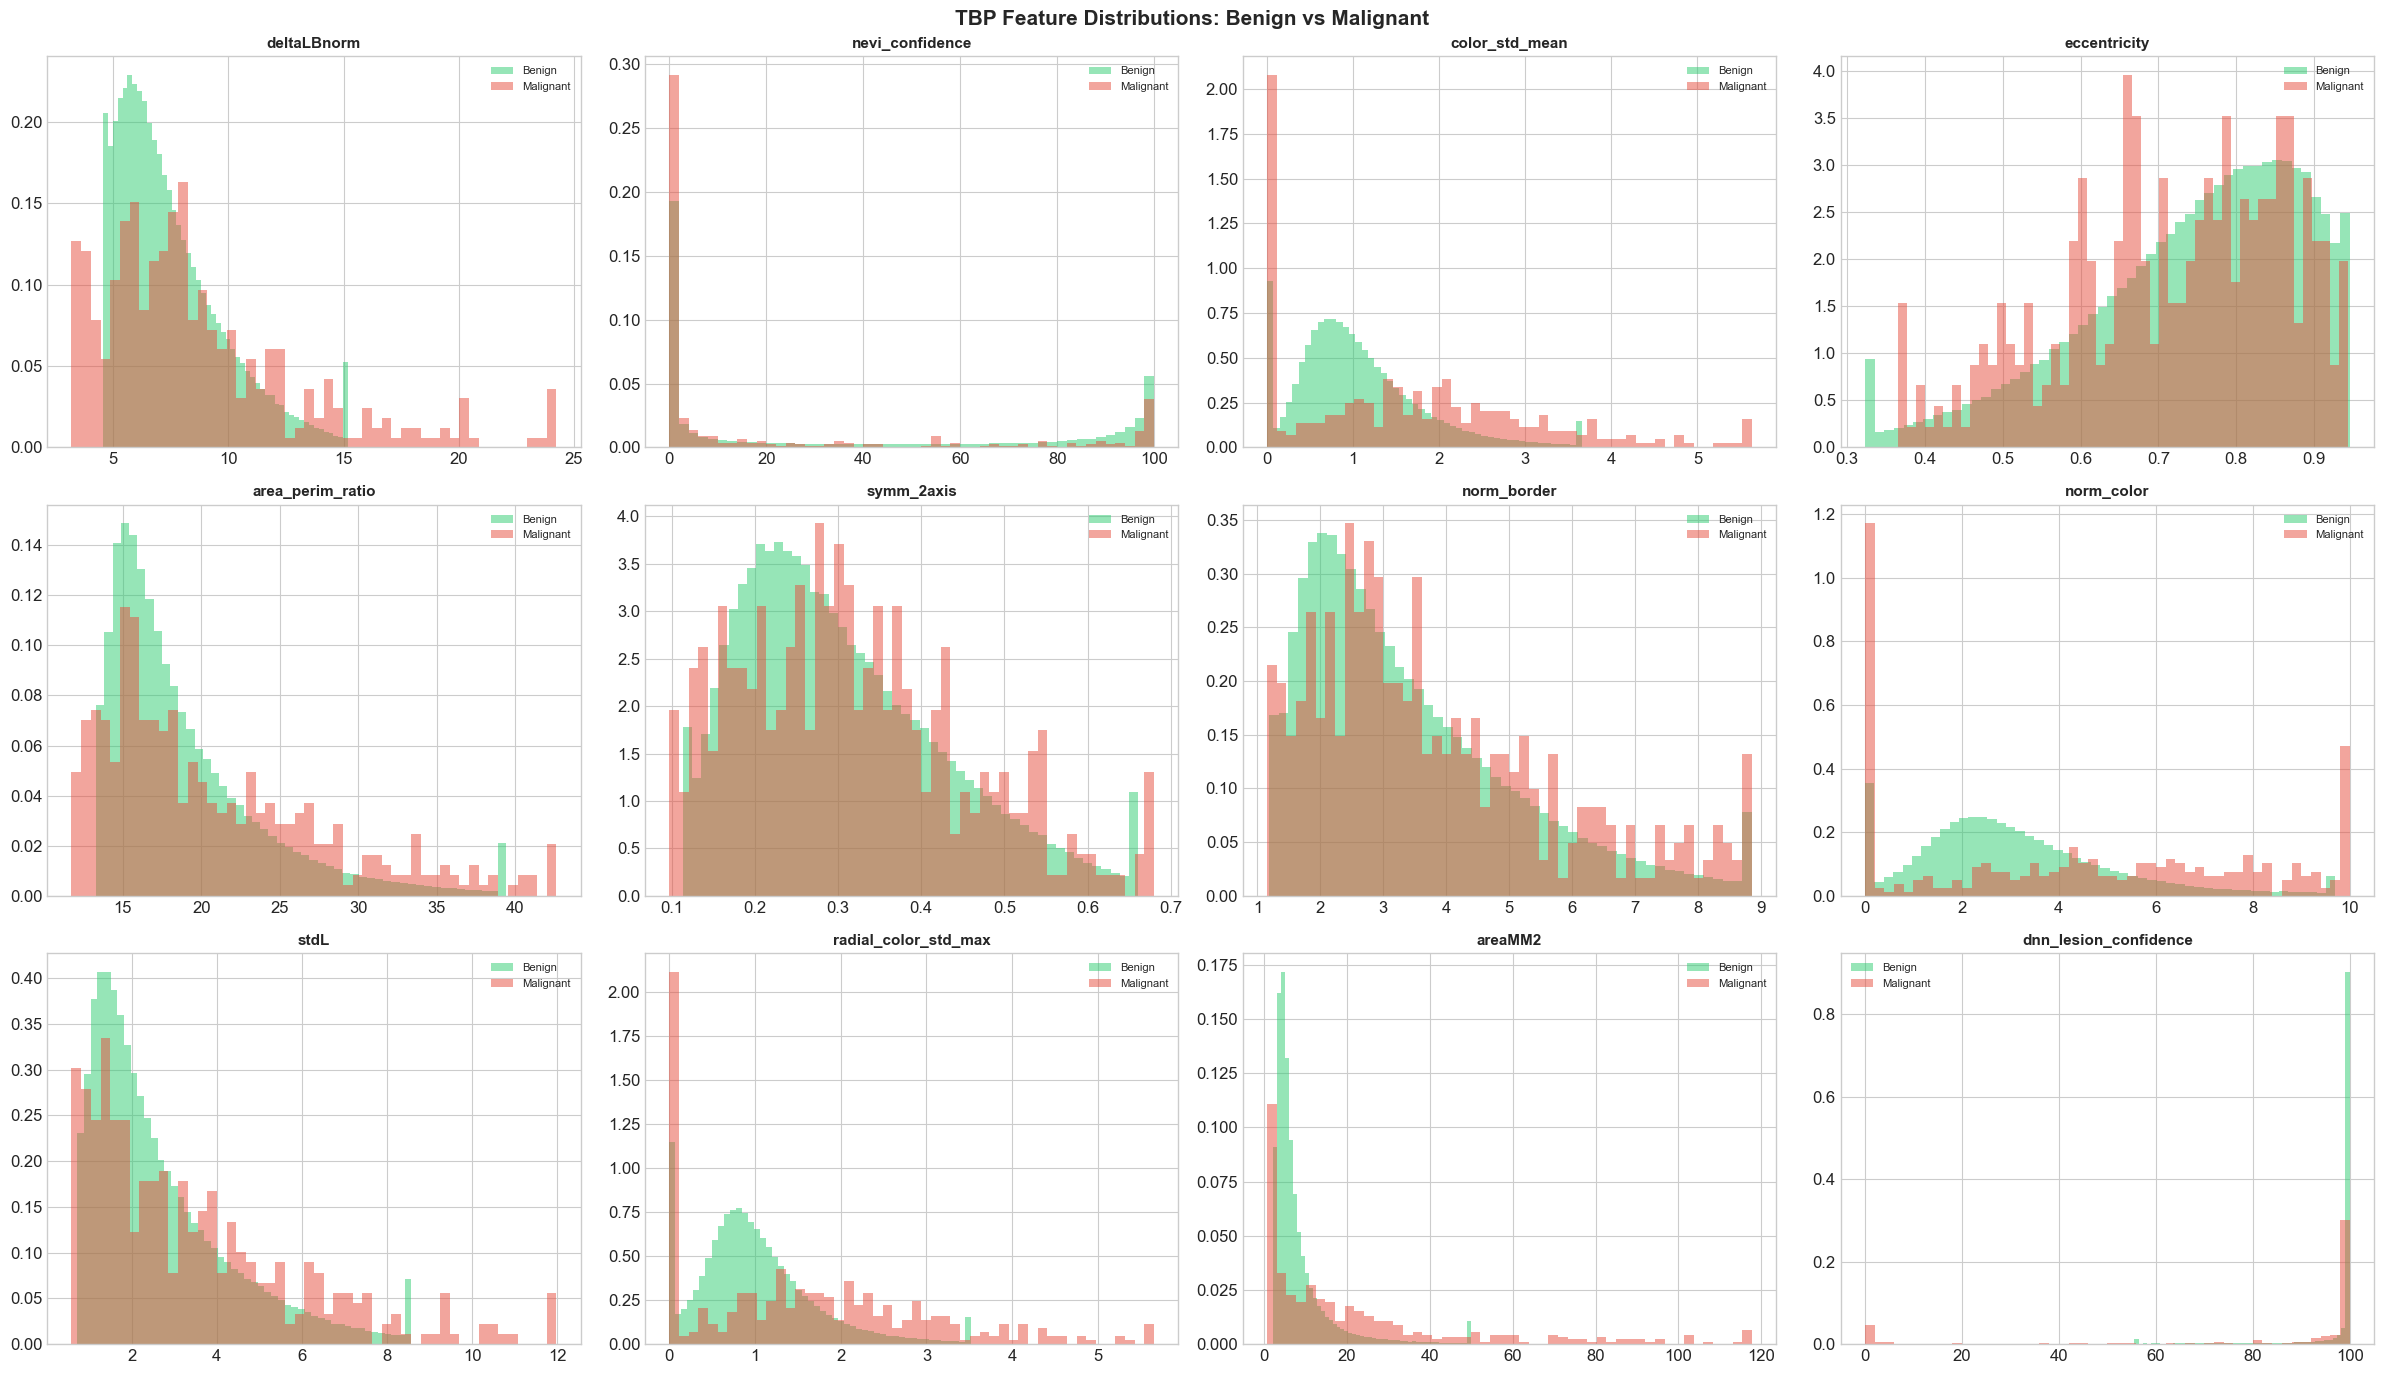

In [7]:
# ============================================================
# 2.4a — TBP Feature Distributions: Benign vs Malignant
# ============================================================
tbp_features = [c for c in df.columns if c.startswith('tbp_lv_') and df[c].dtype in ['float64','int64']]

# Select the 12 most visually interesting features
key_tbp = ['tbp_lv_deltaLBnorm', 'tbp_lv_nevi_confidence', 'tbp_lv_color_std_mean',
           'tbp_lv_eccentricity', 'tbp_lv_area_perim_ratio', 'tbp_lv_symm_2axis',
           'tbp_lv_norm_border', 'tbp_lv_norm_color', 'tbp_lv_stdL',
           'tbp_lv_radial_color_std_max', 'tbp_lv_areaMM2', 'tbp_lv_dnn_lesion_confidence']

fig, axes = plt.subplots(3, 4, figsize=(24, 14))
axes = axes.flatten()

for i, feat in enumerate(key_tbp):
    ax = axes[i]
    for t, color, label in [(0, '#2ecc71', 'Benign'), (1, '#e74c3c', 'Malignant')]:
        data = df[df['target'] == t][feat].dropna()
        q01, q99 = data.quantile(0.01), data.quantile(0.99)
        data_c = data.clip(q01, q99)
        ax.hist(data_c, bins=50, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat.replace('tbp_lv_', ''), fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('TBP Feature Distributions: Benign vs Malignant', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_tbp_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()



### 📌 Key Observations on TBP Features
*   **`nevi_confidence`**: Strong separation — low values indicate malignancy.
*   **`color_std_mean`**: Malignant lesions show higher color heterogeneity.
*   **`symm_2axis`**: Malignant lesions are more asymmetric.
*   **`norm_border`**: Malignant lesions have more irregular borders.
*   **`dnn_lesion_confidence`**: Pre-computed DNN score is highly discriminative.

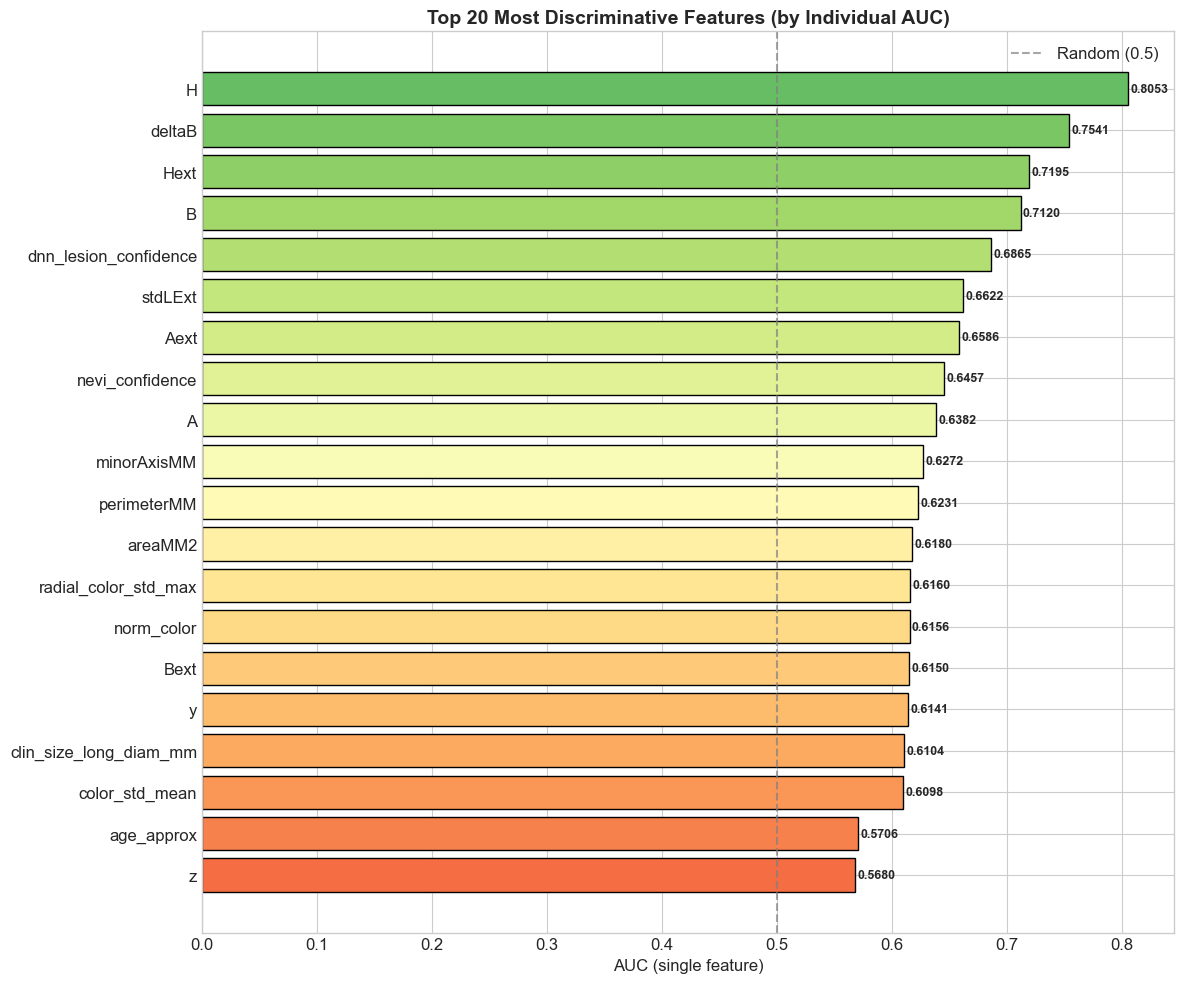

,Feature,AUC
0,tbp_lv_H,0.805261
1,tbp_lv_deltaB,0.754078
2,tbp_lv_Hext,0.719516
3,tbp_lv_B,0.711988
4,tbp_lv_dnn_lesion_confidence,0.686529
5,tbp_lv_stdLExt,0.662190
6,tbp_lv_Aext,0.658557
7,tbp_lv_nevi_confidence,0.645728
8,tbp_lv_A,0.638246
9,tbp_lv_minorAxisMM,0.627197


In [8]:
# ============================================================
# 2.4b — Feature Discriminative Power (AUC per feature)
# ============================================================
from sklearn.metrics import roc_auc_score

numeric_feats = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_feats = [f for f in numeric_feats if f != 'target']

auc_scores = {}
for feat in numeric_feats:
    valid = df[[feat, 'target']].dropna()
    if len(valid) > 100 and valid['target'].nunique() == 2:
        try:
            auc = roc_auc_score(valid['target'], valid[feat])
            auc_scores[feat] = max(auc, 1 - auc)  # Handle inverted features
        except Exception:
            pass

auc_df = pd.DataFrame({'Feature': list(auc_scores.keys()),
                        'AUC': list(auc_scores.values())})
auc_df = auc_df.sort_values('AUC', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 10))
top_20 = auc_df.head(20)
colors_auc = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_20)))
bars = ax.barh(range(len(top_20)), top_20['AUC'].values, color=colors_auc, edgecolor='black')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels([f.replace('tbp_lv_', '') for f in top_20['Feature']])
ax.set_xlabel('AUC (single feature)', fontsize=12)
ax.set_title('Top 20 Most Discriminative Features (by Individual AUC)', fontsize=14, fontweight='bold')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Random (0.5)')
ax.legend()
ax.invert_yaxis()

for bar, auc_val in zip(bars, top_20['AUC'].values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{auc_val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_feature_auc_ranking.png'), dpi=150, bbox_inches='tight')
plt.show()

display(auc_df.head(15))



### 📌 Top discriminative features (univariate AUC)

**Numeric rankings** (feature name and AUC) appear in the **table displayed above** the chart stays the primary visual for the top 20.

**Insight:** Several **TBP color / geometry channels** (e.g. `tbp_lv_H`, `tbp_lv_deltaB`, related L*a*b*-style fields) and **`tbp_lv_dnn_lesion_confidence`** achieve strong single-feature separation. **`tbp_lv_nevi_confidence`** is also among the stronger signals.

**Decision:** Prioritize feature engineering and interactions among these top-ranked numeric fields; always validate with proper cross-validation (and patient-level grouping) since univariate AUC can overstate usable signal.



## 2.5 Correlation Analysis

Understanding inter-feature relationships informs our choice of model (tree-based models handle 
multicollinearity naturally) and identifies redundant features.

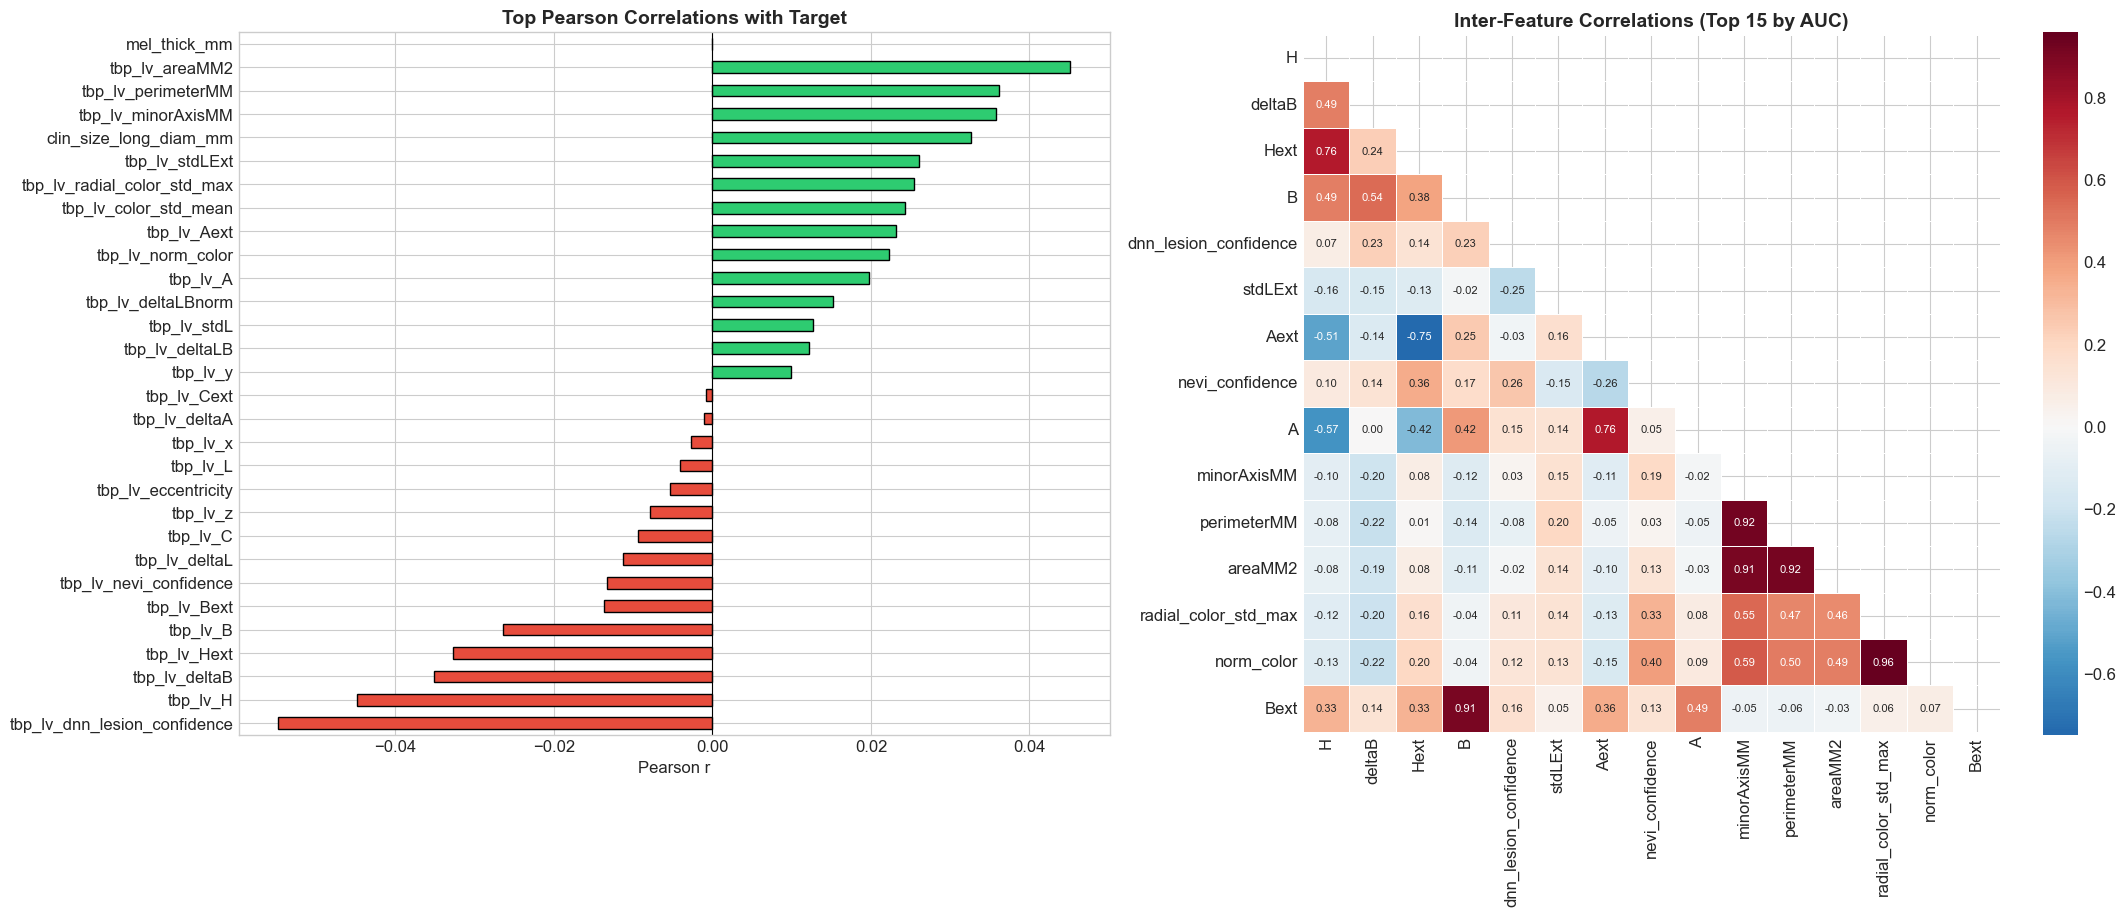

In [9]:
# ============================================================
# 2.5 — Correlation Analysis
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Target correlations
corrs = df[numeric_feats + ['target']].corr()['target'].drop('target').sort_values()
top_corr = pd.concat([corrs.head(15), corrs.tail(15)])
c_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top_corr.values]
top_corr.plot(kind='barh', ax=axes[0], color=c_colors, edgecolor='black')
axes[0].set_title('Top Pearson Correlations with Target', fontweight='bold')
axes[0].set_xlabel('Pearson r')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Inter-feature heatmap (top 15 features by AUC)
top15 = auc_df.head(15)['Feature'].tolist()
corr_mat = df[top15].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], mask=mask, square=True, linewidths=0.5, annot_kws={'size': 8},
            xticklabels=[f.replace('tbp_lv_','') for f in top15],
            yticklabels=[f.replace('tbp_lv_','') for f in top15])
axes[1].set_title('Inter-Feature Correlations (Top 15 by AUC)', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_correlation_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


### 📌 Correlation Insights
1. **Highly Correlated Features**: Several TBP color features are highly correlated (|r| > 0.8).
2. **Tree Models**: Tree-based models (like LightGBM/XGBoost) handle correlated features natively, so there's no strict need to drop them.
3. **Neural Networks**: For DL approaches, high correlation could cause redundant gradients and instability.

**DECISION:** Keep all features for tree models; consider applying PCA or dropping highly correlated features for Neural Networks if needed.

## 2.6 Non-Linear Target Relationships

Linear correlation can miss non-linear patterns. Here we analyze malignancy rate across 
feature quantiles to uncover threshold effects and non-monotonic relationships.

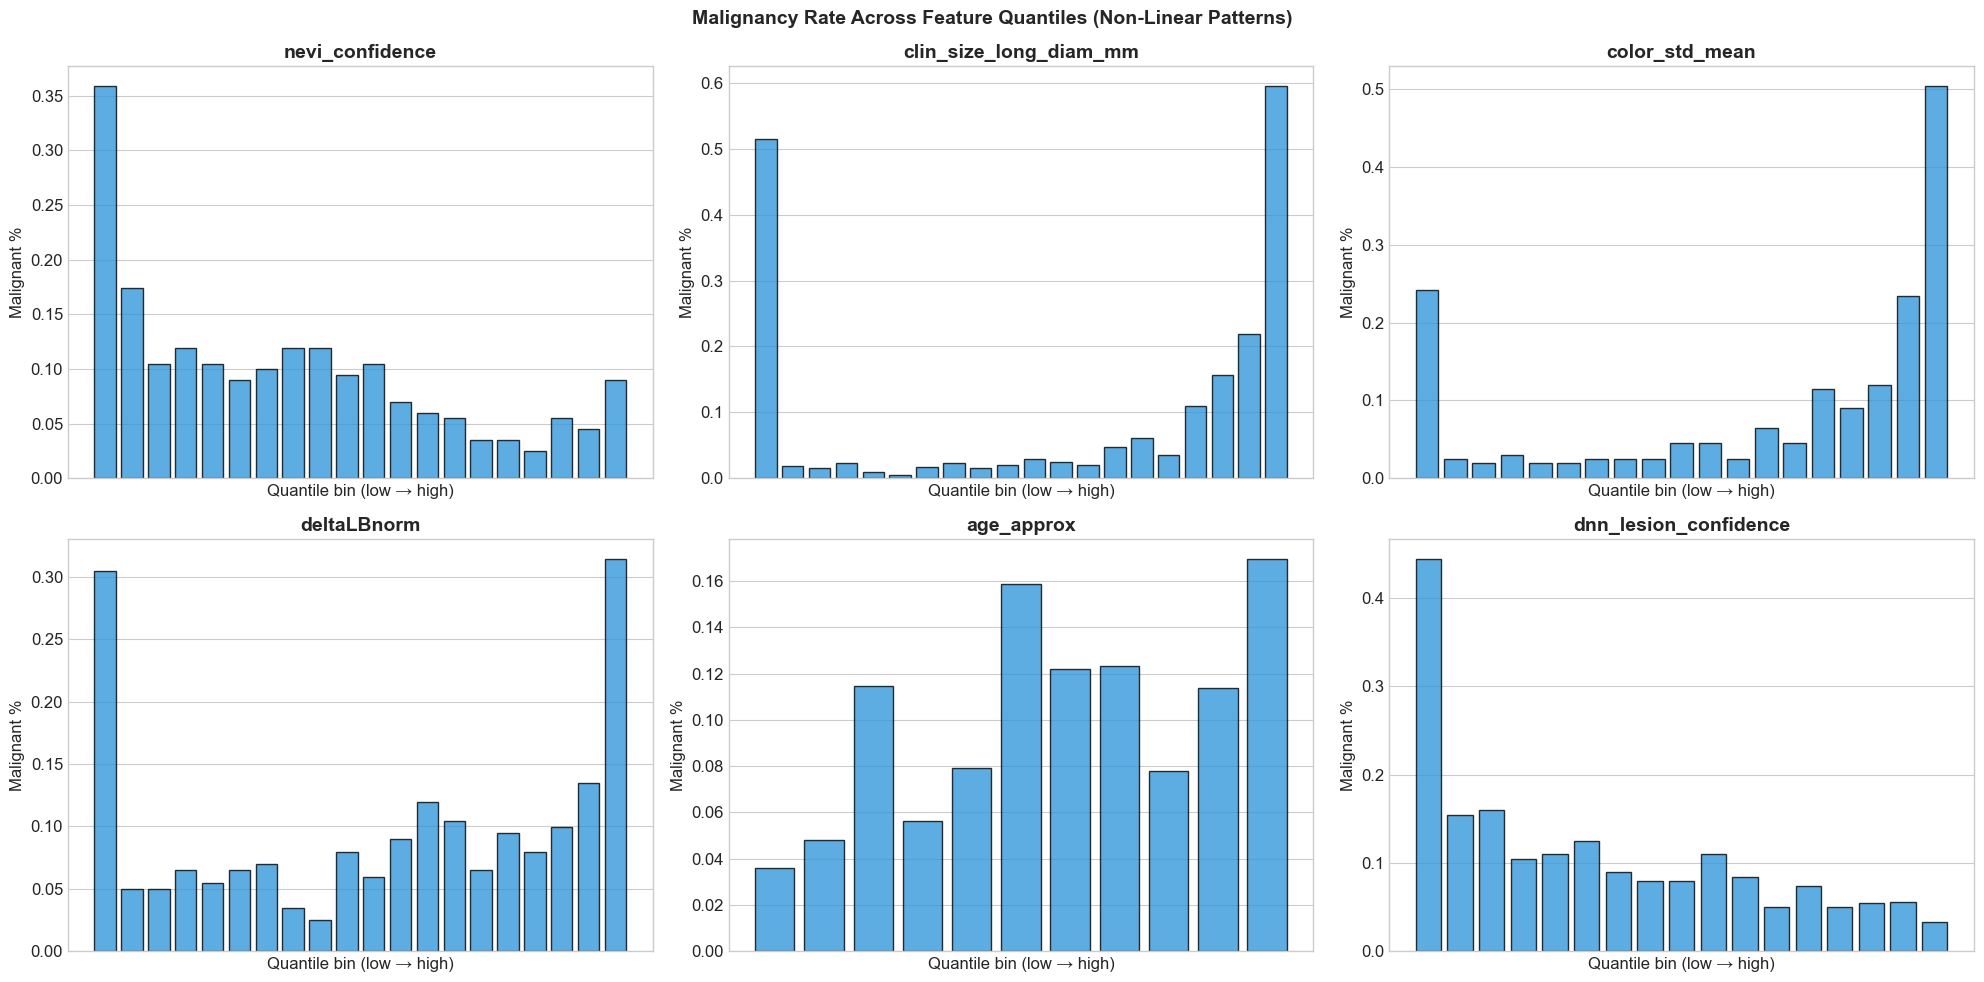

In [10]:
# ============================================================
# 2.6 — Target Rate by Feature Quantiles
# ============================================================
inspect_feats = ['tbp_lv_nevi_confidence', 'clin_size_long_diam_mm',
                 'tbp_lv_color_std_mean', 'tbp_lv_deltaLBnorm',
                 'age_approx', 'tbp_lv_dnn_lesion_confidence']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(inspect_feats):
    ax = axes[i]
    data = df[[feat, 'target']].dropna()
    try:
        data['qbin'] = pd.qcut(data[feat], q=20, duplicates='drop')
        rate = data.groupby('qbin')['target'].mean() * 100
        ax.bar(range(len(rate)), rate.values, color='#3498db', edgecolor='black', alpha=0.8)
        ax.set_title(feat.replace('tbp_lv_', ''), fontweight='bold')
        ax.set_ylabel('Malignant %')
        ax.set_xlabel('Quantile bin (low → high)')
        ax.set_xticks([])
    except Exception as e:
        ax.set_title(f'{feat} (error)', fontweight='bold')
        ax.text(0.5, 0.5, str(e), ha='center', transform=ax.transAxes)

plt.suptitle('Malignancy Rate Across Feature Quantiles (Non-Linear Patterns)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '07_nonlinear_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()


### 📌 Non-Linear Insights

*   **`nevi_confidence`**: Shows a *SHARP spike* in malignancy rate at the lowest quantiles — indicative of a strong threshold effect.
*   **`dnn_lesion_confidence`**: Displays a non-monotonic relationship which warrants further investigation.
*   **`age`**: Demonstrates a monotonically increasing risk with age.

**DECISION:** Tree models will capture these non-linearities and threshold effects naturally, but creating manually binned features may aid linear or neural network models.

## 2.7 Sample Image Visualization

Visual comparison of benign vs malignant lesion images to understand the visual characteristics.

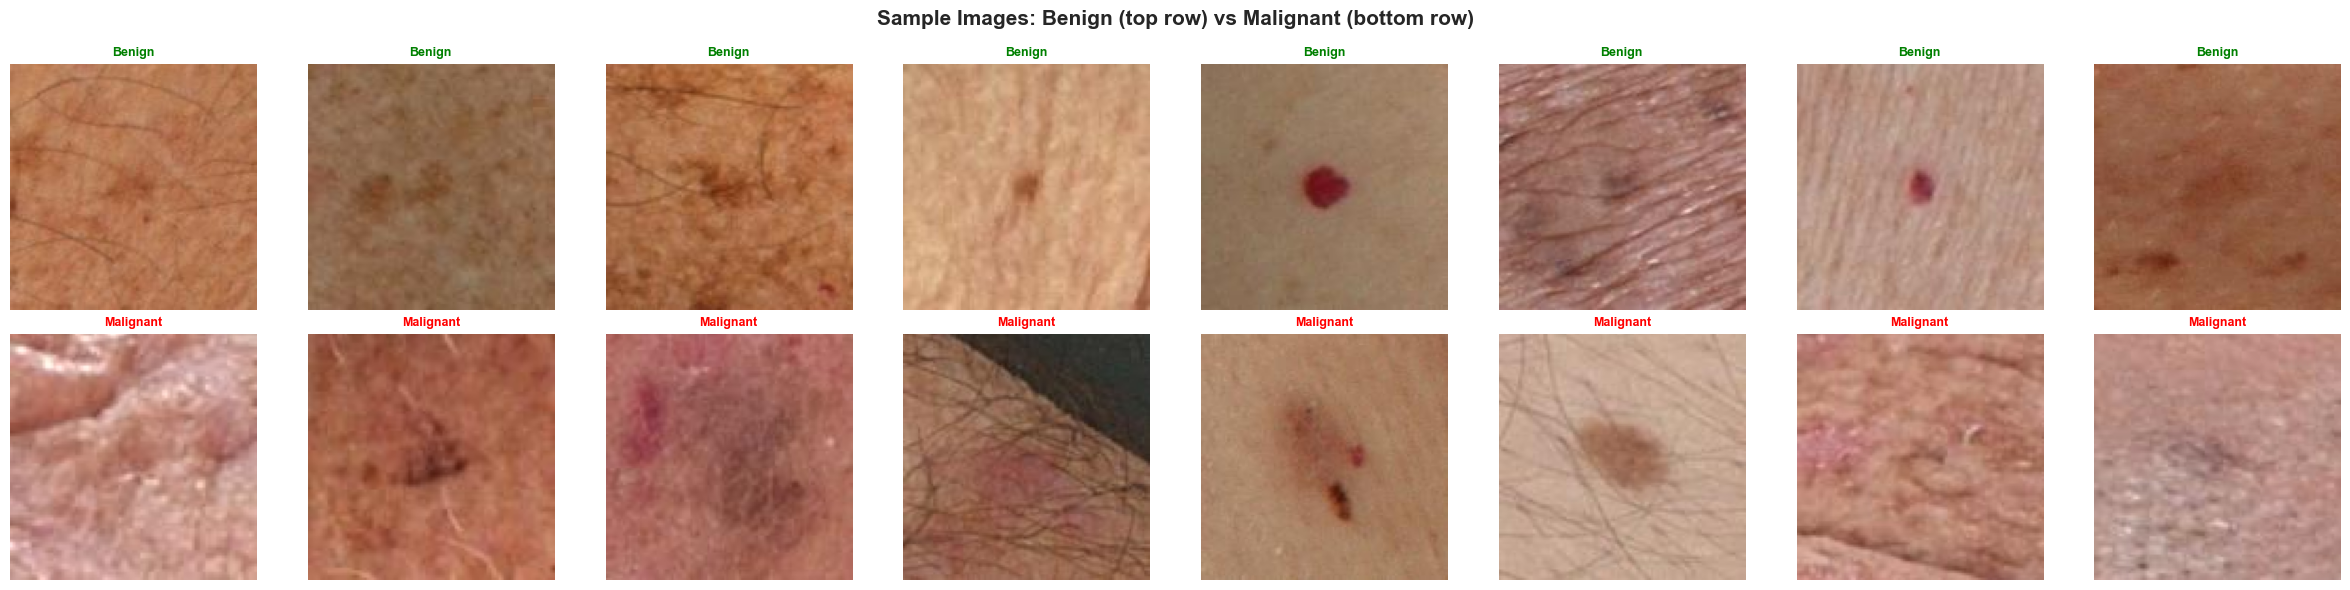

In [11]:
# ============================================================
# 2.7 — Sample Images: Benign vs Malignant
# ============================================================
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train-image', 'image')
TRAIN_HDF5 = os.path.join(DATA_DIR, 'train-image.hdf5')

def load_image(isic_id):
    """Try loading from directory first, then HDF5."""
    jpg_path = os.path.join(TRAIN_IMG_DIR, f"{isic_id}.jpg")
    if os.path.exists(jpg_path):
        return np.array(Image.open(jpg_path))
    try:
        with h5py.File(TRAIN_HDF5, 'r') as f:
            return np.array(Image.open(io.BytesIO(f[isic_id][()])))
    except:
        return None

benign_ids = df[df['target']==0].sample(8, random_state=SEED)['isic_id'].values
malig_ids  = df[df['target']==1].sample(min(8, (df['target']==1).sum()), random_state=SEED)['isic_id'].values

fig, axes = plt.subplots(2, 8, figsize=(24, 6))
fig.suptitle('Sample Images: Benign (top row) vs Malignant (bottom row)',
             fontsize=15, fontweight='bold')

for i, isic_id in enumerate(benign_ids):
    img = load_image(isic_id)
    if img is not None:
        axes[0, i].imshow(img)
    axes[0, i].set_title('Benign', fontsize=9, color='green', fontweight='bold')
    axes[0, i].axis('off')

for i in range(8):
    if i < len(malig_ids):
        img = load_image(malig_ids[i])
        if img is not None:
            axes[1, i].imshow(img)
        axes[1, i].set_title('Malignant', fontsize=9, color='red', fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '08_sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()


### 📌 VISUAL INSIGHTS

*   **Malignant lesions** frequently exhibit color heterogeneity and highly irregular borders.
*   **Benign lesions** often appear visually indistinguishable from malignant cases, rendering classification a highly non-trivial task.
*   **Image augmentation** is strictly required to address variations in lighting, scale, viewing angle, and intrinsic visual appearance.

## 2.8 Patient-Level Analysis

Since multiple lesions can come from the same patient, understanding patient-level patterns 
is critical both for feature engineering AND for preventing data leakage.

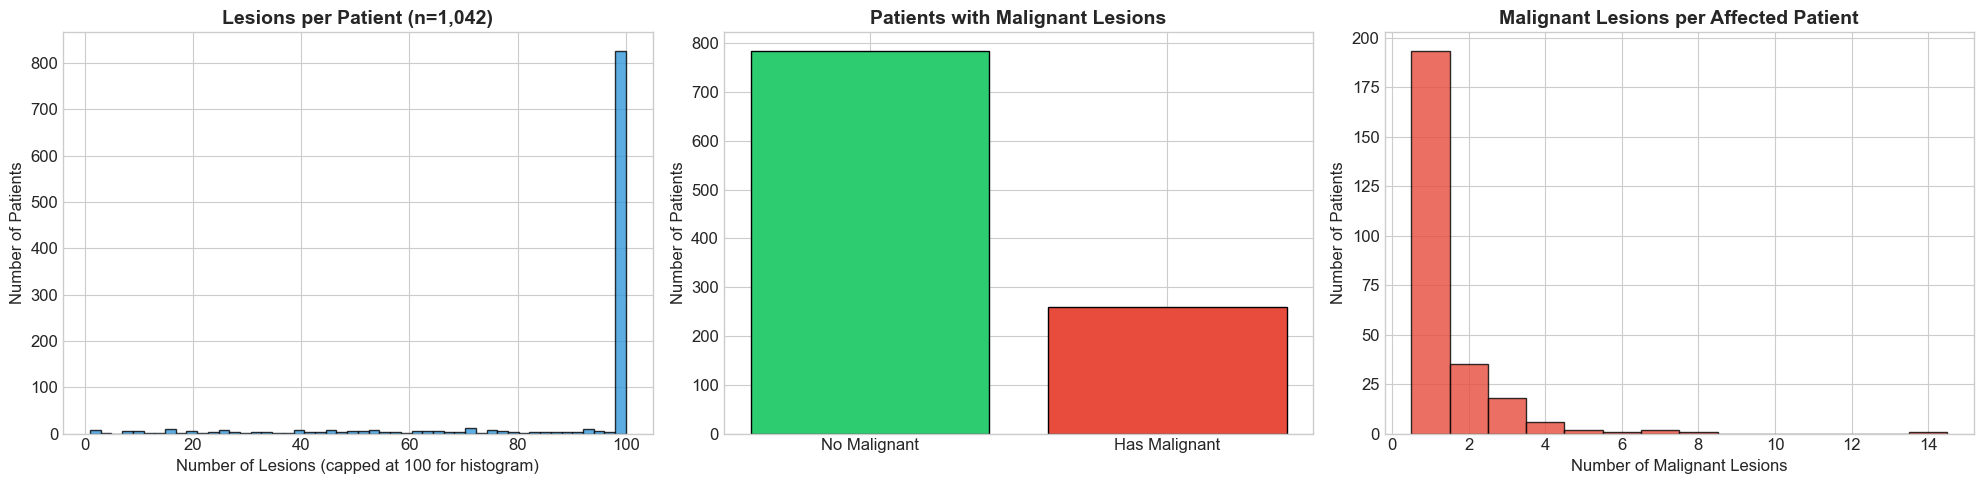

,n_patients,patients_with_any_malignant_lesion,median_lesions_per_patient,max_lesions_single_patient
0,1042,259,241.5,9184


In [12]:
# ============================================================
# 2.8 — Patient-Level Analysis
# ============================================================
patient_stats = df.groupby('patient_id').agg(
    n_lesions=('isic_id', 'count'),
    n_malignant=('target', 'sum'),
    mean_age=('age_approx', 'mean'),
    n_sites=('anatom_site_general', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Lesions per patient
axes[0].hist(patient_stats['n_lesions'].clip(upper=100), bins=50,
            color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title(f'Lesions per Patient (n={len(patient_stats):,})', fontweight='bold')
axes[0].set_xlabel('Number of Lesions (capped at 100 for histogram)')
axes[0].set_ylabel('Number of Patients')

# Patients with malignant lesions
has_malig = patient_stats[patient_stats['n_malignant'] > 0]
axes[1].bar(['No Malignant', 'Has Malignant'],
           [len(patient_stats) - len(has_malig), len(has_malig)],
           color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Patients with Malignant Lesions', fontweight='bold')
axes[1].set_ylabel('Number of Patients')

# Distribution of malignant count per affected patient
if len(has_malig) > 0:
    axes[2].hist(has_malig['n_malignant'], bins=range(1, has_malig['n_malignant'].max()+2),
                color='#e74c3c', edgecolor='black', alpha=0.8, align='left')
    axes[2].set_title('Malignant Lesions per Affected Patient', fontweight='bold')
    axes[2].set_xlabel('Number of Malignant Lesions')
    axes[2].set_ylabel('Number of Patients')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '09_patient_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

patient_summary = pd.DataFrame(
    [
        {
            'n_patients': len(patient_stats),
            'patients_with_any_malignant_lesion': len(has_malig),
            'median_lesions_per_patient': patient_stats['n_lesions'].median(),
            'max_lesions_single_patient': patient_stats['n_lesions'].max(),
        }
    ]
)
display(patient_summary)



### 📌 Patient-level structure — interpretation

The **exact patient counts and lesion-per-patient summaries** are in the **table displayed above** (computed from the current `train-metadata.csv`).

**Insights:**
- Many images belong to the **same `patient_id`**, so rows are **not independent**.
- **Leakage risk:** random train/test splits can put different lesions from one patient in both sets.
- Malignant cases are concentrated among a **subset of patients**; modeling should respect patient grouping.

**Decisions:**
- Use **grouped cross-validation** (e.g. `StratifiedGroupKFold` with `patient_id`) for honest estimates.
- Consider **patient-level aggregates** (counts, rates, z-scores within patient) as additional features where appropriate.



## 2.9 EDA Summary: Insights → Decisions

### Reference: insights → modeling decisions

| Domain | Insight | Strategic decision |
| :--- | :--- | :--- |
| **Class imbalance** | ~1020:1 benign vs malignant | Class weighting / focal loss; stratified **grouped** CV; ranking metrics (AUC / pAUC) — not accuracy alone |
| **Demographics** | Higher malignancy rate in older ages on average | Keep `age_approx`; bins/interactions if using linear models |
| **Demographics** | Site and sex associate with malignancy rate | Fold-aware encoding for categoricals |
| **TBP morphology** | Strong univariate signal from color/geometry features | Ratios, interactions; validate under grouped CV |
| **Confidence scores** | `nevi_confidence`, `dnn_lesion_confidence` rank highly | Keep; optional interactions with other fields |
| **Correlations** | TBP color channels often highly correlated | Trees: usually keep all; NNs: consider decorrelation |
| **Non-linearities** | Quantile plots show thresholds / non-monotone regions | Trees; or explicit bins for linear/DL |
| **Patient grouping** | Many rows per `patient_id` | **Never** IID split; group by `patient_id` |
| **Missing data** | Some fields incomplete | Imputation or missing-aware models; track missingness |



---
**Next Notebook:** `03_Feature_Engineering.ipynb` — Transform raw features into discriminative representations.